# Actor-Critic Policy Evaluation

Evaluate whether the trained policy actually controls the agent meaningfully in imagination.

**Goal**: Demonstrate that the policy can be trained and executed in imagination (the core thesis contribution)

We will:
1. Load trained checkpoints
2. Generate policy-controlled rollouts (learned behavior)
3. Compare against prior rollouts (no learned policy)
4. Visualize action sequences, imagined observations, and predicted values
5. Check if policy learns meaningful behaviors

In [1]:
import json
import yaml
import ruamel.yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
import pickle
import jax
import jax.numpy as jnp
from functools import partial
import importlib

# Setup paths correctly (matching world_model_reconstruction.ipynb)
notebook_dir = Path('/home/maurits-heemskerk/Documents/Uni/Master_Thesis/dreamer_SPOT_implementation/notebooks')
dreamer_dir = Path('/home/maurits-heemskerk/Documents/Uni/Master_Thesis/dreamer_SPOT_implementation/informed-dreamer')

import sys
sys.path.insert(0, str(dreamer_dir))

# Dreamer imports
from dreamerv3 import ninjax as nj
import dreamerv3
import embodied

print(f"✓ JAX version: {jax.__version__}")
print(f"✓ Devices: {jax.devices()}")
print(f"✓ Imports successful")

✓ JAX version: 0.4.28
✓ Devices: [cuda(id=0)]
✓ Imports successful


In [2]:

import re

results_dir = Path('/home/maurits-heemskerk/Documents/Uni/Master_Thesis/dreamer_results_local_noobs')
available_runs = sorted([d for d in results_dir.iterdir() if d.is_dir()])

print("Available training runs:")
for i, run in enumerate(available_runs):
    ckpt_path   = run / 'checkpoint.ckpt'
    config_path = run / 'config.yaml'
    if ckpt_path.exists() and config_path.exists():
        with open(config_path) as f:
            rc = ruamel.yaml.YAML(typ='safe').load(f)
        enc_mlp = rc.get('encoder', {}).get('mlp_keys', '?')
        print(f"  [{i:2d}] {run.name}  (enc_mlp={enc_mlp!r})")
    else:
        print(f"  [{i:2d}] {run.name} ⚠ (missing checkpoint or config)")

print(f"\n✓ {len(available_runs)} runs found")
print("\n👇 SELECT RUNS TO EVALUATE:")

run_indices_to_eval = [12]  # ← modify to select runs
print(f"   run_indices_to_eval = {run_indices_to_eval}")


Available training runs:
  [ 0] rewardsv2_large_baseline  (enc_mlp='velocity|orientation|goal')
  [ 1] rewardsv2_large_dyn_rep  (enc_mlp='velocity|orientation|goal')
  [ 2] rewardsv2_large_multistep  (enc_mlp='velocity|orientation|goal')
  [ 3] rewardsv2_large_realtd  (enc_mlp='velocity|orientation|goal')
  [ 4] rewardsv2_large_warmup  (enc_mlp='velocity|orientation|goal')
  [ 5] rewardsv2_medium_baseline  (enc_mlp='velocity|orientation|goal')
  [ 6] rewardsv2_medium_dyn_rep  (enc_mlp='velocity|orientation|goal')
  [ 7] rewardsv2_medium_multistep  (enc_mlp='velocity|orientation|goal')
  [ 8] rewardsv2_medium_realtd  (enc_mlp='velocity|orientation|goal')
  [ 9] rewardsv2_medium_warmup  (enc_mlp='velocity|orientation|goal')
  [10] rewardsv3_kl_baseline  (enc_mlp='velocity|orientation|goal')
  [11] rewardsv3_kl_high_both  (enc_mlp='velocity|orientation|goal')
  [12] rewardsv3_kl_high_dyn  (enc_mlp='velocity|orientation|goal')
  [13] rewardsv3_kl_high_rep  (enc_mlp='velocity|orientation|go

In [3]:
# Helper function to load checkpoint and config
def load_checkpoint_and_config(checkpoint_path, config_path):
    with open(config_path) as f:
        raw_config = ruamel.yaml.YAML(typ='safe').load(f)
    with open(checkpoint_path, 'rb') as f:
        checkpoint_data = pickle.load(f)
    return checkpoint_data, raw_config


def _filter_to_known(cfg, ref):
    """Recursively drop keys not present in ref (handles old checkpoints with missing/extra keys)."""
    out = {}
    for k, v in cfg.items():
        if k not in ref:
            continue
        if isinstance(v, dict) and isinstance(ref[k], dict):
            out[k] = _filter_to_known(v, ref[k])
        else:
            out[k] = v
    return out


def prepare_world_model(checkpoint_path, config_path):
    from dreamerv3.agent import WorldModel

    checkpoint_data, raw_config = load_checkpoint_and_config(checkpoint_path, config_path)

    _defaults = embodied.Config(dreamerv3.Agent.configs['defaults'])
    _known_keys = set(_defaults.keys()) - {'env'}
    _filtered = _filter_to_known({k: v for k, v in raw_config.items() if k in _known_keys}, dict(_defaults))

    config = embodied.Config(dreamerv3.Agent.configs['defaults'])
    config = config.update(_filtered)

    # Fixed obs/act space — matched exactly to new checkpoints
    # Obs: velocity (3,)=[vx,vy,wz]  orientation (2,)=[cos,sin]  goal (2,)=[dx,dy]
    # Act: action   (3,)=[vx,vy,yaw_rate]  — no gait switching
    obs_space = {
        'velocity':    embodied.Space(np.float32, (3,)),   # [vx, vy, wz]
        'orientation': embodied.Space(np.float32, (2,)),   # [cos(yaw), sin(yaw)]
        'goal':        embodied.Space(np.float32, (2,)),   # [dx, dy] world-relative
        'position':    embodied.Space(np.float32, (2,)),   # reference only
        'image':       embodied.Space(np.uint8,   (49, 128, 3)),
        'terrain':     embodied.Space(np.float32, (64, 64)),
        'info_terrain':embodied.Space(np.float32, (64, 64)),
        'reward':      embodied.Space(np.float32),
        'is_first':    embodied.Space(bool),
        'is_last':     embodied.Space(bool),
        'is_terminal': embodied.Space(bool),
    }
    act_space = {'action': embodied.Space(np.float32, (3,), -1.0, 1.0), 'reset': embodied.Space(bool)}

    wm = WorldModel(obs_space, act_space, config, name='wm')

    raw_agent_state = checkpoint_data['agent']
    agent_state = {}
    wm_keys_found = 0
    for k, v in raw_agent_state.items():
        if k.startswith('agent/wm/'):
            agent_state[k.replace('agent/wm/', 'wm/', 1)] = v
            wm_keys_found += 1

    print(f"  ✓ {wm_keys_found} WM parameter tensors mapped")
    return wm, agent_state, config


In [4]:
selected_runs = []
run_agents   = {}
run_wms      = {}
run_states   = {}
run_configs  = {}
run_obs_keys = {}

# Fixed obs/act space — matched exactly to new checkpoints
# velocity (3,): [vx, vy, wz]  orientation (2,): [cos(yaw), sin(yaw)]  goal (2,): [dx, dy]
# action  (3,): [vx, vy, yaw_rate]  — no gait switching
_SPACE_MAP = {
    'velocity':    embodied.Space(np.float32, (3,)),
    'orientation': embodied.Space(np.float32, (2,)),
    'goal':        embodied.Space(np.float32, (2,)),
    'position':    embodied.Space(np.float32, (2,)),
    'image':       embodied.Space(np.uint8,   (49, 128, 3)),
    'terrain':     embodied.Space(np.float32, (64, 64)),
    'info_terrain':embodied.Space(np.float32, (64, 64)),
}
_ALL_MLP = ['velocity', 'orientation', 'goal', 'position']
_ALL_CNN = ['image', 'terrain', 'info_terrain']

for run_idx in run_indices_to_eval:
    if run_idx >= len(available_runs):
        print(f"⚠ Run index {run_idx} out of range"); continue

    run_path    = available_runs[run_idx]
    ckpt_path   = run_path / 'checkpoint.ckpt'
    config_path = run_path / 'config.yaml'

    if not (ckpt_path.exists() and config_path.exists()):
        print(f"⚠ Run {run_idx} missing checkpoint or config"); continue

    print(f"\nLoading run {run_idx}: {run_path.name}")
    print("-" * 60)
    try:
        with open(config_path) as f:
            raw_config = ruamel.yaml.YAML(typ='safe').load(f)

        _defaults = embodied.Config(dreamerv3.Agent.configs['defaults'])
        _known_keys = set(_defaults.keys()) - {'env'}
        _filtered = _filter_to_known({k: v for k, v in raw_config.items() if k in _known_keys}, dict(_defaults))

        config = embodied.Config(dreamerv3.Agent.configs['defaults'])
        config = config.update(_filtered)
        config = config.update({'jax.platform': 'cpu', 'jax.prealloc': False})

        _enc_mlp = raw_config['encoder']['mlp_keys']
        _enc_cnn = raw_config['encoder']['cnn_keys']
        mlp_keys = [k for k in _ALL_MLP if _enc_mlp and re.search(_enc_mlp, k)]
        cnn_keys = [k for k in _ALL_CNN if _enc_cnn and re.search(_enc_cnn, k)]
        obs_keys = mlp_keys + cnn_keys
        run_obs_keys[run_idx] = obs_keys

        obs_space = {k: _SPACE_MAP[k] for k in obs_keys if k in _SPACE_MAP}
        obs_space['reward']      = embodied.Space(np.float32)
        obs_space['is_first']    = embodied.Space(bool)
        obs_space['is_last']     = embodied.Space(bool)
        obs_space['is_terminal'] = embodied.Space(bool)
        act_space = {'action': embodied.Space(np.float32, (3,), -1.0, 1.0), 'reset': embodied.Space(bool)}

        print(f"  Obs keys: {obs_keys}")
        print(f"  Act space: action {act_space['action'].shape}  (vx, vy, yaw_rate)")

        with open(ckpt_path, 'rb') as f:
            ckpt_data = pickle.load(f)

        ckpt_state  = ckpt_data['agent']
        agent_state = {}
        wm_keys = ac_keys = 0
        for k, v in ckpt_state.items():
            if k.startswith('agent/'):
                new_k = k[6:]
                agent_state[new_k] = v
                if 'wm/' in k:           wm_keys += 1
                if 'task_behavior' in k: ac_keys  += 1

        step  = embodied.Counter()
        agent = dreamerv3.Agent(obs_space, act_space, step, config)
        jax.config.update('jax_transfer_guard', 'allow')

        from dreamerv3.agent import WorldModel
        wm = WorldModel(obs_space, act_space, config, name='wm')

        run_agents[run_idx]  = (agent, agent_state)
        run_wms[run_idx]     = wm
        run_states[run_idx]  = agent_state
        run_configs[run_idx] = config
        selected_runs.append(run_idx)

        print(f"  ✓ WM parameters: {wm_keys}")
        print(f"  ✓ Actor-Critic parameters: {ac_keys}")
        print(f"  ✓ Task behavior: {config.task_behavior}")

    except Exception as e:
        print(f"  ✗ Error: {e}")
        import traceback; traceback.print_exc()

print(f"\n{'='*60}")
print(f"✓ Loaded {len(selected_runs)} agents successfully")



Loading run 12: rewardsv3_kl_high_dyn
------------------------------------------------------------
  Obs keys: ['velocity', 'orientation', 'goal']
  Act space: action (3,)  (vx, vy, yaw_rate)
Could not disable TensorFlow devices: No module named 'tensorflow'
Encoder CNN shapes: {}
Encoder MLP shapes: {'velocity': (3,), 'orientation': (2,), 'goal': (2,)}
Decoder CNN shapes: {}
Decoder MLP shapes: {'velocity': (3,), 'orientation': (2,), 'goal': (2,)}
JAX devices (1): [CpuDevice(id=0)]
Policy devices: TFRT_CPU_0
Train devices:  TFRT_CPU_0
Tracing policy function.
Encoder CNN shapes: {}
Encoder MLP shapes: {'velocity': (3,), 'orientation': (2,), 'goal': (2,)}
Decoder CNN shapes: {}
Decoder MLP shapes: {'velocity': (3,), 'orientation': (2,), 'goal': (2,)}
  ✓ WM parameters: 79
  ✓ Actor-Critic parameters: 46
  ✓ Task behavior: Greedy

✓ Loaded 1 agents successfully


## Policy Rollout Functions

Generate trajectories under:
1. **Prior**: No learned policy (sample random actions from prior)
2. **Policy**: Learned actor-critic policy controls action selection

In [5]:

def rollout_with_prior(wm, agent_state, obs_batch, action_batch, obs_keys,
                       horizon=70, seed=0, start_step=30):
    """
    Random-action prior rollout through the world model.
    """
    _state_keys = [k for k in obs_keys if k in ['velocity', 'orientation', 'goal', 'position']]

    def prior_imagination():
        first_obs    = {k: v[:, start_step:start_step + 1] for k, v in obs_batch.items()}
        first_action = jnp.zeros((obs_batch['is_first'].shape[0], 1, 3), dtype=jnp.float32)
        embed_first  = wm.encoder(first_obs)
        post_first, _ = wm.rssm.observe(embed_first, first_action, first_obs['is_first'])
        start_state  = {k: v[:, 0] for k, v in post_first.items()}

        batch_size     = obs_batch['is_first'].shape[0]
        random_actions = jnp.tanh(jax.random.normal(nj.rng(), shape=(batch_size, horizon, 3)))
        priors         = wm.rssm.imagine(random_actions, start_state)
        recons_dists   = wm.heads['decoder'](priors)
        extra = {k: recons_dists[k].mean() for k in _state_keys if k in recons_dists}
        return extra, jnp.transpose(random_actions, (1, 0, 2))

    rng_key = jax.random.PRNGKey(seed)
    (extra, actions), _ = nj.pure(prior_imagination)(agent_state, rng_key)

    rollout = {'mode': 'prior', 'actions': actions}
    for k, v in extra.items():
        rollout[k] = np.array(v).squeeze(0)
    return rollout, {}

print("✓ Prior rollout ready (random actions, 3-dim act space)")


✓ Prior rollout ready (random actions, 3-dim act space)


In [6]:

def rollout_with_policy(agent, wm, agent_state, obs_batch, action_batch, obs_keys,
                        horizon=70, seed=1, start_step=10):
    """
    Policy-driven rollout through the world model.
    Action space: (3,) = [vx, vy, yaw_rate] — no gait switching.
    """
    eval_state = dict(agent_state)
    for k, v in agent_state.items():
        if k.startswith('task_behavior/'):
            eval_state['agent/' + k] = v

    _state_keys = [k for k in obs_keys if k in ['velocity', 'orientation', 'goal', 'position']]

    def policy_imagination():
        first_obs    = {k: v[:, start_step:start_step + 1] for k, v in obs_batch.items()}
        first_action = jnp.zeros((obs_batch['is_first'].shape[0], 1, 3), dtype=jnp.float32)
        embed_first  = wm.encoder(first_obs)
        post_first, _ = wm.rssm.observe(embed_first, first_action, first_obs['is_first'])
        latent = {k: v[:, 0] for k, v in post_first.items()}

        actor      = agent.agent.task_behavior.ac.actor
        critic_net = agent.agent.task_behavior.ac.critics['extr'].net

        latent_list, action_list, value_list, entropy_list = [], [], [], []

        for _ in range(horizon):
            action_dist = actor(latent)
            action  = action_dist.mode()
            entropy = action_dist.entropy()
            value   = critic_net(latent).mean()

            latent_list.append(latent)
            action_list.append(action)
            value_list.append(value)
            entropy_list.append(entropy)

            next_latent = wm.rssm.imagine(jnp.expand_dims(action, axis=1), latent)
            latent = {k: v[:, 0] for k, v in next_latent.items()}

        reward_list = [wm.heads['reward'](l).mean() for l in latent_list]

        latents_BH   = {k: jnp.stack([l[k] for l in latent_list], axis=1) for k in latent_list[0]}
        recons_dists = wm.heads['decoder'](latents_BH)
        extra = {k: recons_dists[k].mean() for k in _state_keys if k in recons_dists}

        return (
            jnp.stack(action_list),    # (H, B, 3)
            jnp.stack(value_list),     # (H, B)
            jnp.stack(reward_list),    # (H, B)
            jnp.stack(entropy_list),   # (H, B)
            extra,
        )

    rng_key = jax.random.PRNGKey(seed)
    (actions, values, rewards, entropies, extra), _ = nj.pure(policy_imagination)(eval_state, rng_key)

    rollout = {
        'mode':      'policy',
        'actions':   actions,
        'values':    values,
        'rewards':   rewards,
        'entropies': entropies,
    }
    for k, v in extra.items():
        rollout[k] = np.array(v).squeeze(0)

    return rollout, agent_state

print("✓ Policy rollout ready (actor-critic, 3-dim act space: vx, vy, yaw_rate)")


✓ Policy rollout ready (actor-critic, 3-dim act space: vx, vy, yaw_rate)


## Load Data Sample for Initialization

We need example observations from the dataset to initialize the world model's posterior.

In [7]:

import h5py

data_dir = Path('/home/maurits-heemskerk/Documents/Uni/Master_Thesis/dreamer_SPOT_implementation/informed-dreamer/processed_data')
h5_files = sorted(data_dir.glob('**/*.h5'))

if not h5_files:
    print("⚠ No h5 files found.")
    _raw_data = None
else:
    episode_file = h5_files[0]
    print(f"Loading: {episode_file.name}")

    with h5py.File(episode_file, 'r') as f:
        velocities_raw = f['observations/velocities'][:].astype(np.float32)  # (T, 6)
        states         = f['observations/state'][:].astype(np.float32)        # (T, 7)
        actions_data   = f['actions'][:].astype(np.float32)

    seq_length = len(velocities_raw)

    # ── Exact feature extraction — matched to new checkpoints ─────────────────
    # velocity (3,): [vx, vy, wz]  — drop vz (idx 2), wx/wy pitch+roll (idx 3,4)
    velocities = velocities_raw[:, [0, 1, 5]].astype(np.float32)

    # orientation (2,): [cos(yaw), sin(yaw)] — absolute, not episode-relative
    qx, qy, qz, qw = states[:, 3], states[:, 4], states[:, 5], states[:, 6]
    yaw = np.arctan2(2.0 * (qw * qz + qx * qy), 1.0 - 2.0 * (qy * qy + qz * qz))
    orientations = np.stack([np.cos(yaw), np.sin(yaw)], axis=-1).astype(np.float32)

    # position (2,): zero-centred — reference only, not fed to encoder
    xy_raw    = states[:, :2]
    positions = (xy_raw - xy_raw[0]).astype(np.float32)

    # goal (2,): world-frame displacement to episode-final position
    dx = xy_raw[-1, 0] - xy_raw[:, 0]
    dy = xy_raw[-1, 1] - xy_raw[:, 1]
    goal_relative = np.stack([dx, dy], axis=-1).astype(np.float32)

    _raw_data = {
        'velocity':    velocities,
        'orientation': orientations,
        'goal':        goal_relative,
        'position':    positions,
    }
    # Slice actions to 3-dim (vx, vy, yaw_rate) in case H5 stores 4-dim
    actions_batch_real = np.expand_dims(actions_data[:seq_length, :3], 0)

    print(f"✓ Episode length: {seq_length}")
    print(f"✓ Available observation arrays: {list(_raw_data.keys())}")
    print(f"✓ Velocity shape: {velocities.shape}  (vx, vy, wz)")
    print(f"✓ Orientation shape: {orientations.shape}  (cos, sin)")
    print(f"✓ Action shape: {actions_batch_real.shape}  (vx, vy, yaw_rate)")


def make_obs_batch(obs_keys, seq_len=None):
    """Build obs_batch for the given obs_keys from the loaded episode."""
    n = seq_len or seq_length
    batch = {k: np.expand_dims(_raw_data[k][:n], 0)
             for k in obs_keys if k in _raw_data}
    batch['is_first']    = np.zeros((1, n), dtype=bool)
    batch['is_last']     = np.zeros((1, n), dtype=bool)
    batch['is_terminal'] = np.zeros((1, n), dtype=bool)
    batch['reward']      = np.zeros((1, n), dtype=np.float32)
    batch['is_first'][0, 0]  = True
    batch['is_last'][0, -1]  = True
    return batch

print(f"\n✓ make_obs_batch() ready")


Loading: spot_bag_20260217_133435_expert_med_converted.h5
✓ Episode length: 65
✓ Available observation arrays: ['velocity', 'orientation', 'goal', 'position']
✓ Velocity shape: (65, 3)  (vx, vy, wz)
✓ Orientation shape: (65, 2)  (cos, sin)
✓ Action shape: (1, 65, 3)  (vx, vy, yaw_rate)

✓ make_obs_batch() ready


## Visualization Setup

Tools for visualizing rollouts

In [8]:

import os
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image as IPyImage

# 3-dim action space: vx, vy, yaw_rate — no gait
ACTION_LABELS = ['vel_x (fwd)', 'vel_y (lat)', 'vel_yaw']


def _orientation_to_yaw(ori):
    ori = np.asarray(ori)
    if ori.ndim != 2:
        raise ValueError(f"Expected orientation shape (H, D), got {ori.shape}")
    if ori.shape[1] == 2:
        return np.arctan2(ori[:, 1], ori[:, 0])
    if ori.shape[1] == 4:
        qx, qy, qz, qw = ori[:, 0], ori[:, 1], ori[:, 2], ori[:, 3]
        return np.arctan2(
            2.0 * (qw * qz + qx * qy),
            1.0 - 2.0 * (qy ** 2 + qz ** 2),
        )
    raise ValueError(f"Unsupported orientation dim {ori.shape[1]}; expected 2 or 4")


def plot_action_sequences(rollout_policy, run_label, max_steps=30):
    fig, ax = plt.subplots(figsize=(14, 4))
    policy_actions = np.array(rollout_policy['actions'][:max_steps, 0, :])
    colors = ['tab:blue', 'tab:orange', 'tab:green']
    for i, (label, color) in enumerate(zip(ACTION_LABELS, colors)):
        ax.plot(policy_actions[:, i], label=label, color=color, linewidth=1.5, alpha=0.85)
    ax.set_title(f"{run_label} — Policy Actions (Learned)", fontsize=11, fontweight='bold')
    ax.set_ylabel('Action value'); ax.set_xlabel('Imagination step')
    ax.set_ylim(-1.2, 1.2); ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3); ax.axhline(y=0, color='k', linestyle='--', alpha=0.2)
    plt.tight_layout()
    return fig


def plot_value_predictions(rollout_policy, run_label, max_steps=30):
    fig, ax = plt.subplots(figsize=(12, 4))
    values  = np.array(rollout_policy['values'][:max_steps, 0])
    rewards = np.array(rollout_policy['rewards'][:max_steps, 0])
    ax.plot(values,  label='Critic value estimate', linewidth=2, marker='o', markersize=4)
    ax.plot(rewards, label='Imagined reward',        linewidth=2, marker='s', markersize=4, alpha=0.7)
    ax.set_title(f"{run_label} — Value & Reward During Policy Rollout", fontsize=11, fontweight='bold')
    ax.set_xlabel('Imagination step'); ax.set_ylabel('Value / Reward')
    ax.legend(loc='best', fontsize=10); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return fig


def create_policy_state_gif(rollout_policy, run_label, obs_batch_ref=None,
                             output_path='/tmp/policy_dream.gif', fps=3, dt=0.5):
    has_pos  = 'position'    in rollout_policy
    has_vel  = 'velocity'    in rollout_policy
    has_ori  = 'orientation' in rollout_policy
    has_goal = 'goal'        in rollout_policy

    actions_arr  = np.array(rollout_policy['actions'])   # (H, B, 3)
    values_arr   = np.array(rollout_policy['values'])    # (H, B)
    rewards_arr  = np.array(rollout_policy['rewards'])   # (H, B)
    horizon      = actions_arr.shape[0]
    print(f"  Creating GIF: {horizon} frames at {fps} fps...")

    yaw = _orientation_to_yaw(rollout_policy['orientation']) if has_ori else np.zeros(horizon)

    if has_pos:
        position = rollout_policy['position']
        traj_x, traj_y = position[:, 0], position[:, 1]
        dr_x, dr_y = np.zeros(horizon), np.zeros(horizon)
        dr_x[0], dr_y[0] = traj_x[0], traj_y[0]
        for _t in range(horizon - 1):
            vx, vy = float(actions_arr[_t, 0, 0]), float(actions_arr[_t, 0, 1])
            cy, sy = np.cos(yaw[_t]), np.sin(yaw[_t])
            dr_x[_t+1] = dr_x[_t] + (vx*cy - vy*sy) * dt
            dr_y[_t+1] = dr_y[_t] + (vx*sy + vy*cy) * dt

    yaw = _orientation_to_yaw(rollout_policy['orientation']) if has_ori else np.zeros(horizon)
    heading_len = 0.75
    heading_line = None
    orient_line = orient_tip = None

    fig, axes_g = plt.subplots(2, 3, figsize=(20, 10))
    fig.suptitle(f"{run_label} — Policy Dream Recording", fontsize=12, fontweight='bold')
    ax_traj, ax_vel, ax_goal, ax_orient, ax_info, ax_blank = axes_g.flatten()

    # ── Trajectory ───────────────────────────────────────────────────────────
    if has_pos:
        if obs_batch_ref is not None and 'position' in obs_batch_ref:
            gt_pos = obs_batch_ref['position'][0] if obs_batch_ref['position'].ndim == 3 \
                     else obs_batch_ref['position']
            ax_traj.plot(gt_pos[:, 0], gt_pos[:, 1], 'b--', linewidth=1.5, alpha=0.5, label='Real (init)')
            all_x = np.concatenate([traj_x, dr_x, gt_pos[:, 0]])
            all_y = np.concatenate([traj_y, dr_y, gt_pos[:, 1]])
        else:
            all_x = np.concatenate([traj_x, dr_x])
            all_y = np.concatenate([traj_y, dr_y])
        pad = max(0.5, (all_x.max()-all_x.min())*0.15 + 0.5)
        ax_traj.set_xlim(all_x.min()-pad, all_x.max()+pad)
        ax_traj.set_ylim(all_y.min()-pad, all_y.max()+pad)
        ax_traj.plot(traj_x, traj_y, 'r-', linewidth=1, alpha=0.15)
        ax_traj.plot(dr_x,   dr_y,   color='gold', linewidth=1, alpha=0.15, linestyle='--')
        line_traj,  = ax_traj.plot([], [], 'r-', linewidth=2, label='Decoded pos')
        point_traj, = ax_traj.plot([], [], 'r*', markersize=10)
        line_dr,    = ax_traj.plot([], [], color='gold', linewidth=2, linestyle='--', label='Cmd dead-reckoned')
        point_dr,   = ax_traj.plot([], [], '*', color='gold', markersize=10)
        if has_ori:
            heading_len = max(0.4, pad * 0.25)
            heading_line, = ax_traj.plot([], [], color='deepskyblue', linewidth=2, label='Heading')
        ax_traj.set_aspect('equal', adjustable='datalim'); ax_traj.legend(fontsize=7)
    else:
        ax_traj.text(0.5, 0.5, 'Position not used', ha='center', va='center',
                     transform=ax_traj.transAxes)
        line_traj = point_traj = line_dr = point_dr = None
        traj_x = traj_y = None
    ax_traj.set_title('Position  (red=decoded  gold=cmd)', fontsize=10, fontweight='bold')
    ax_traj.set_xlabel('X (m)'); ax_traj.set_ylabel('Y (m)'); ax_traj.grid(True, alpha=0.3)

    # ── Velocity time series ─────────────────────────────────────────────────
    vel_lines_dec = []
    vel_lines_cmd = []
    for dim, c in enumerate(['tab:blue', 'tab:orange']):
        l_d, = ax_vel.plot([], [], '-',  color=c, linewidth=2, label=f'Decoded vel[{dim}]')
        l_c, = ax_vel.plot([], [], '--', color=c, linewidth=1.5, label=f'Cmd vel[{dim}]', alpha=0.7)
        vel_lines_dec.append(l_d); vel_lines_cmd.append(l_c)
    ax_vel.set_xlim(0, horizon-1); ax_vel.set_ylim(-1.3, 1.3)
    ax_vel.set_title('Velocity x/y  (decoded vs commanded)', fontsize=10, fontweight='bold')
    ax_vel.set_xlabel('Step'); ax_vel.set_ylabel('m/s  /  cmd-unit')
    ax_vel.legend(fontsize=7, loc='upper right'); ax_vel.grid(True, alpha=0.3)

    # ── Goal (ego-centric) ───────────────────────────────────────────────────
    if has_goal:
        goal_arr = rollout_policy['goal']
        g_range  = max(1.0, float(np.abs(goal_arr).max()) + 0.5)
        ax_goal.scatter(0, 0, color='blue', s=200, marker='o', zorder=5,
                        edgecolors='black', linewidths=2, label='Robot (0,0)')
        point_goal, = ax_goal.plot([], [], '*', color='gold', markersize=14,
                                   label='Goal (decoded)', zorder=7,
                                   markeredgecolor='black', markeredgewidth=0.5)
        ax_goal.set_xlim(-g_range, g_range); ax_goal.set_ylim(-g_range, g_range)
        ax_goal.set_aspect('equal', adjustable='datalim'); ax_goal.legend(fontsize=7)
    else:
        ax_goal.text(0.5, 0.5, 'Goal not used', ha='center', va='center',
                     transform=ax_goal.transAxes)
        point_goal = None
    ax_goal.set_title('Goal (Ego-Centric)', fontsize=10, fontweight='bold')
    ax_goal.set_xlabel('X (m)'); ax_goal.set_ylabel('Y (m)'); ax_goal.grid(True, alpha=0.3)

    # ── Orientation compass ─────────────────────────────────────────────────
    if has_ori:
        ax_orient.set_aspect('equal', adjustable='box')
        ax_orient.add_patch(plt.Circle((0, 0), 1.0, fill=False, color='lightgray',
                                       linestyle='--', linewidth=1))
        ax_orient.axhline(0, color='k', linewidth=0.5, alpha=0.3)
        ax_orient.axvline(0, color='k', linewidth=0.5, alpha=0.3)
        orient_line, = ax_orient.plot([], [], color='deepskyblue', linewidth=2, label='Heading')
        orient_tip, = ax_orient.plot([], [], 'o', color='deepskyblue', markersize=6)
        ax_orient.set_xlim(-1.2, 1.2); ax_orient.set_ylim(-1.2, 1.2)
        ax_orient.legend(fontsize=7, loc='upper right')
    else:
        ax_orient.text(0.5, 0.5, 'Orientation not used', ha='center', va='center',
                       transform=ax_orient.transAxes)
        orient_line = orient_tip = None
    ax_orient.set_title('Orientation (decoded heading)', fontsize=10, fontweight='bold')
    ax_orient.set_xlabel('cos(yaw)'); ax_orient.set_ylabel('sin(yaw)'); ax_orient.grid(True, alpha=0.3)

    ax_blank.axis('off')

    # ── Info panel ───────────────────────────────────────────────────────────
    ax_info.axis('off')
    step_text = ax_info.text(0.5, 0.93, '', ha='center', fontsize=12,
                             fontweight='bold', transform=ax_info.transAxes)
    info_text = ax_info.text(0.05, 0.75, '', ha='left', fontsize=9,
                             family='monospace', transform=ax_info.transAxes)

    def update_frame(t):
        act_t = actions_arr[t, 0, :]   # (3,)

        if line_traj is not None:
            line_traj.set_data(traj_x[:t+1], traj_y[:t+1])
            point_traj.set_data([traj_x[t]], [traj_y[t]])
            line_dr.set_data(dr_x[:t+1], dr_y[:t+1])
            point_dr.set_data([dr_x[t]], [dr_y[t]])
            if heading_line is not None:
                hx = traj_x[t] + heading_len * np.cos(yaw[t])
                hy = traj_y[t] + heading_len * np.sin(yaw[t])
                heading_line.set_data([traj_x[t], hx], [traj_y[t], hy])

        for dim in range(2):
            vel_lines_dec[dim].set_data(range(t+1),
                [rollout_policy['velocity'][s, dim] if has_vel else 0.0 for s in range(t+1)])
            vel_lines_cmd[dim].set_data(range(t+1),
                [float(actions_arr[s, 0, dim]) for s in range(t+1)])

        if point_goal is not None:
            point_goal.set_data([goal_arr[t, 0]], [goal_arr[t, 1]])
        if orient_line is not None:
            orient_line.set_data([0, np.cos(yaw[t])], [0, np.sin(yaw[t])])
            orient_tip.set_data([np.cos(yaw[t])], [np.sin(yaw[t])])

        step_text.set_text(f'Step {t} / {horizon-1}')
        pos_str  = f'Pos:  ({traj_x[t]:.2f}, {traj_y[t]:.2f})' if traj_x is not None else 'Pos: N/A'
        goal_str = f'Goal: ({goal_arr[t,0]:.2f}, {goal_arr[t,1]:.2f})' if has_goal else 'Goal: N/A'
        vel_str  = (f'Vel:  ({rollout_policy["velocity"][t,0]:.2f}, {rollout_policy["velocity"][t,1]:.2f})'
                    if has_vel else 'Vel: N/A')
        yaw_str  = f'Yaw:  {np.degrees(yaw[t]):+.1f} deg' if has_ori else 'Yaw: N/A'
        info_text.set_text(
            f'{pos_str}\n{vel_str}\n'
            f'Cmd:  vx={act_t[0]:+.2f}  vy={act_t[1]:+.2f}  yaw={act_t[2]:+.2f}\n'
            f'{yaw_str}\n'
            f'{goal_str}\n'
            f'Value:  {values_arr[t,0]:.3f}\n'
            f'Reward: {rewards_arr[t,0]:.3f}'
        )
        return [step_text, info_text]

    anim = FuncAnimation(fig, update_frame, frames=horizon,
                         interval=int(1000/fps), blit=False, repeat=True)
    anim.save(output_path, writer=PillowWriter(fps=fps))
    sz = os.path.getsize(output_path) / (1024*1024)
    print(f"  ✓ GIF saved: {output_path} ({sz:.1f} MB, {horizon/fps:.1f}s at {fps} fps)")
    plt.close(fig)
    from IPython.display import display as ipy_display
    ipy_display(IPyImage(filename=output_path))


print("✓ Visualization functions defined  (3-dim action space)")


✓ Visualization functions defined  (3-dim action space)


In [9]:

def compute_latent_drift(wm, agent_state, obs_batch, action_batch, seed=0):
    def latent_rollouts():
        embed = wm.encoder(obs_batch)
        post, prior = wm.rssm.observe(embed, action_batch, obs_batch['is_first'])
        start = {k: v[:, 0] for k, v in post.items()}
        prior_imagined = wm.rssm.imagine(action_batch, start)
        return post, prior_imagined

    rng_key = jax.random.PRNGKey(seed)
    (post_latents, prior_latents), _ = nj.pure(latent_rollouts)(agent_state, rng_key)

    T = post_latents['deter'].shape[1]
    deter_drift, stoch_drift = [], []
    for t in range(T):
        deter_drift.append(float(np.linalg.norm(np.array(post_latents['deter'][:, t] - prior_latents['deter'][:, t]))))
        post_s = post_latents['stoch'][:, t]; prior_s = prior_latents['stoch'][:, t]
        stoch_drift.append(float(np.linalg.norm(np.array(post_s - prior_s).reshape(post_s.shape[0], -1))))

    return {'deter': np.array(deter_drift), 'stoch': np.array(stoch_drift)}


def compute_reconstruction_error(wm, agent_state, obs_batch, action_batch, obs_keys, seed=0):
    def recon_fn():
        embed = wm.encoder(obs_batch)
        post, _ = wm.rssm.observe(embed, action_batch, obs_batch['is_first'])
        return wm.heads['decoder'](post)

    rng_key = jax.random.PRNGKey(seed)
    recon_dists, _ = nj.pure(recon_fn)(agent_state, rng_key)

    errors = {}
    for key in obs_keys:
        if key not in recon_dists or key not in obs_batch:
            continue
        pred = np.array(recon_dists[key].mean())
        gt   = np.array(obs_batch[key])
        mse_per_step = np.mean((pred - gt) ** 2, axis=tuple(range(2, gt.ndim)))
        errors[key] = mse_per_step[0]
    return errors


def rollout_stability_metrics(rollout_policy):
    """Stability metrics for 3-dim action space (vx, vy, yaw_rate)."""
    actions   = np.array(rollout_policy['actions'])[:, 0, :]   # (H, 3)
    rewards   = np.array(rollout_policy['rewards'])[:, 0]
    entropies = np.array(rollout_policy.get('entropies', np.zeros(len(rewards))))
    entropies = entropies[:, 0] if entropies.ndim == 2 else entropies

    smoothness   = float(np.mean(np.diff(actions, axis=0) ** 2))
    action_var   = float(np.mean(np.var(actions, axis=0)))
    reward_trend = float(np.polyfit(np.arange(len(rewards)), rewards, deg=1)[0])
    mean_entropy = float(np.mean(entropies))
    saturation   = float(np.mean(np.abs(actions) > 0.95))

    return {
        'action_smoothness':   smoothness,
        'action_variance':     action_var,
        'reward_trend':        reward_trend,
        'mean_policy_entropy': mean_entropy,
        'action_saturation':   saturation,
    }


def plot_latent_drift(drift_dict, run_label):
    fig, axes = plt.subplots(1, 2, figsize=(14, 3))
    for ax, (key, drift) in zip(axes, drift_dict.items()):
        ax.plot(drift, linewidth=2)
        ax.set_title(f"{run_label} — Latent Drift ({key})", fontsize=10, fontweight='bold')
        ax.set_xlabel("Timestep"); ax.set_ylabel("L2 Distance"); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()


def plot_policy_entropy(rollout_policy, run_label):
    entropies = np.array(rollout_policy.get('entropies', []))
    if entropies.size == 0:
        print("  ⚠ No entropy data in rollout."); return
    ent = entropies[:, 0]
    plt.figure(figsize=(10, 3))
    plt.plot(ent, linewidth=2, color='darkorange')
    plt.axhline(float(np.mean(ent)), linestyle='--', color='gray', alpha=0.6,
                label=f'mean = {float(np.mean(ent)):.3f}')
    plt.title(f"{run_label} — Actor Policy Entropy", fontsize=11, fontweight='bold')
    plt.xlabel("Imagination step"); plt.ylabel("Entropy (nats)")
    plt.legend(fontsize=9); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()


def plot_reconstruction_error(errors, run_label):
    keys = list(errors.keys())
    if not keys: return
    fig, axes = plt.subplots(1, len(keys), figsize=(4*len(keys), 3))
    if len(keys) == 1: axes = [axes]
    for ax, key in zip(axes, keys):
        ax.plot(errors[key], linewidth=2)
        ax.set_title(f"{key} MSE", fontsize=10, fontweight='bold')
        ax.set_xlabel("Timestep"); ax.set_ylabel("MSE"); ax.grid(True, alpha=0.3)
    fig.suptitle(f"{run_label} — Decoder Reconstruction Error (real obs)",
                 fontsize=11, fontweight='bold')
    plt.tight_layout(); plt.show()


print("✓ Diagnostics functions defined  (3-dim action space, no gait metric)")


✓ Diagnostics functions defined  (3-dim action space, no gait metric)


## Command–State Alignment

Do commanded actions produce the expected motion in the decoded state?

Five panels:
1. **Trajectory**: decoded position (red) vs. dead-reckoned position from vel_x/vel_y commands (blue dashed). Dead-reckoning uses decoded yaw to rotate body-frame commands into world frame with a fixed `dt` (step interval). If the world model is consistent, both traces should point in the same direction even if they diverge over time due to delay.
2. **Speed alignment**: decoded forward speed (red, `velocity[:, 0]`) vs. commanded forward speed (blue, `actions[:, 0]`). Expect positive correlation with a lag.
3. **Lateral speed alignment**: same for lateral axis.
4. **Orientation**: decoded yaw over time, compared against the reference orientation when available.
5. **Goal distance**: decoded ego-centric goal distance over time. Should decrease if the policy is navigating toward the goal.


In [10]:
def plot_command_state_alignment(rollout_policy, run_label, obs_batch_ref=None, dt=0.5):
    """
    Five-panel figure showing how well the decoded world-model state tracks
    the intention expressed in the commanded actions.

    Parameters
    ----------
    rollout_policy : dict
        Output of rollout_with_policy.
    run_label : str
        Title prefix.
    dt : float
        Assumed seconds per imagination step. Training used ~2 Hz real data
        → dt ≈ 0.5 s is a reasonable default; adjust to match your dataset.

    Panels
    ------
    1. XY trajectory: decoded position (solid red) vs. dead-reckoned from
       vel_x / vel_y commands starting at the first decoded position (dashed
       blue), rotated into world frame using the decoded yaw at each step.
    2. Forward speed: decoded velocity_x (red) vs. commanded vel_x (blue).
    3. Lateral speed: decoded velocity_y (red) vs. commanded vel_y (blue).
    4. Orientation: decoded yaw over time, compared against the reference
       orientation when available.
    5. Goal distance: ego-centric goal vector norm over time; should shrink
       if the policy is successfully navigating toward the goal.
    """
    has_pos  = 'position'    in rollout_policy
    has_vel  = 'velocity'    in rollout_policy
    has_ori  = 'orientation' in rollout_policy
    has_goal = 'goal'        in rollout_policy
    has_ref_ori = obs_batch_ref is not None and 'orientation' in obs_batch_ref

    actions = np.array(rollout_policy['actions'])[:, 0, :]
    H = len(actions)
    steps = np.arange(H)

    fig, axes = plt.subplots(2, 3, figsize=(24, 8))
    axes = axes.flatten()
    fig.suptitle(
        f"{run_label}\nCommand–State Alignment  (dt={dt:.2f} s/step)",
        fontsize=12, fontweight='bold',
    )

    # ── Panel 1: XY trajectory ───────────────────────────────────────────────
    ax = axes[0]
    if has_pos:
        pos = rollout_policy['position']
        ax.plot(pos[:, 0], pos[:, 1], 'r-o', linewidth=2, markersize=4, label='Decoded position')
        ax.plot(pos[0, 0], pos[0, 1], 'rs', markersize=10, zorder=5, label='Start', markeredgecolor='k')

        yaw = _orientation_to_yaw(rollout_policy['orientation']) if has_ori else np.zeros(H)
        dr_pos = np.zeros((H, 2))
        dr_pos[0] = pos[0, :2]
        for t in range(H - 1):
            cos_y, sin_y = np.cos(yaw[t]), np.sin(yaw[t])
            dx = (float(actions[t, 0]) * cos_y - float(actions[t, 1]) * sin_y) * dt
            dy = (float(actions[t, 0]) * sin_y + float(actions[t, 1]) * cos_y) * dt
            dr_pos[t + 1] = dr_pos[t] + np.array([dx, dy])

        ax.plot(dr_pos[:, 0], dr_pos[:, 1], 'b--o', linewidth=2, markersize=4, alpha=0.75, label='Dead-reckoned (cmd)')
        ax.plot(dr_pos[0, 0], dr_pos[0, 1], 'bs', markersize=10, zorder=5, markeredgecolor='k')
        ax.set_aspect('equal', adjustable='datalim')
        ax.legend(fontsize=8)
    else:
        ax.text(0.5, 0.5, 'Position not available', ha='center', va='center', transform=ax.transAxes)
        yaw = _orientation_to_yaw(rollout_policy['orientation']) if has_ori else np.zeros(H)
    ax.set_title('XY Trajectory', fontsize=10, fontweight='bold')
    ax.set_xlabel('X (m)')
    ax.set_ylabel('Y (m)')
    ax.grid(True, alpha=0.3)

    # ── Panel 2: Forward speed ───────────────────────────────────────────────
    ax = axes[1]
    if has_vel:
        vel_x_decoded = rollout_policy['velocity'][:, 0]
        ax.plot(steps, vel_x_decoded, 'r-', linewidth=2, label='Decoded vel_x')
    ax.plot(steps, actions[:, 0], 'b--', linewidth=2, label='Commanded vel_x', alpha=0.85)
    if has_vel:
        corr_fwd = np.corrcoef(vel_x_decoded, actions[:, 0])[0, 1]
        ax.set_title(f'Forward Speed  (r={corr_fwd:.2f})', fontsize=10, fontweight='bold')
    else:
        ax.set_title('Forward Speed (cmd only)', fontsize=10, fontweight='bold')
    ax.set_xlabel('Imagination step')
    ax.set_ylabel('Speed (m/s)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color='k', linestyle='--', alpha=0.2)

    # ── Panel 3: Lateral speed ───────────────────────────────────────────────
    ax = axes[2]
    if has_vel:
        vel_y_decoded = rollout_policy['velocity'][:, 1]
        ax.plot(steps, vel_y_decoded, 'r-', linewidth=2, label='Decoded vel_y')
    ax.plot(steps, actions[:, 1], 'b--', linewidth=2, label='Commanded vel_y', alpha=0.85)
    if has_vel:
        corr_lat = np.corrcoef(vel_y_decoded, actions[:, 1])[0, 1]
        ax.set_title(f'Lateral Speed  (r={corr_lat:.2f})', fontsize=10, fontweight='bold')
    else:
        ax.set_title('Lateral Speed (cmd only)', fontsize=10, fontweight='bold')
    ax.set_xlabel('Imagination step')
    ax.set_ylabel('Speed (m/s)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color='k', linestyle='--', alpha=0.2)

    # ── Panel 4: Orientation ────────────────────────────────────────────────
    ax = axes[3]
    if has_ori:
        yaw_deg = np.degrees(np.unwrap(yaw))
        ax.plot(steps, yaw_deg, 'm-', linewidth=2, label='Decoded yaw')
        if has_ref_ori:
            ref_ori = obs_batch_ref['orientation'][0] if obs_batch_ref['orientation'].ndim == 3 else obs_batch_ref['orientation']
            ref_yaw_deg = np.degrees(np.unwrap(_orientation_to_yaw(ref_ori)))
            ref_steps = np.arange(min(len(ref_yaw_deg), H))
            ax.plot(ref_steps, ref_yaw_deg[:len(ref_steps)], 'k--', linewidth=1.5, alpha=0.8, label='Reference yaw')
        ax.legend(fontsize=8)
    else:
        ax.text(0.5, 0.5, 'Orientation not available', ha='center', va='center', transform=ax.transAxes)
    ax.set_title('Orientation / Yaw', fontsize=10, fontweight='bold')
    ax.set_xlabel('Imagination step')
    ax.set_ylabel('Yaw (deg)')
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color='k', linestyle='--', alpha=0.2)

    # ── Panel 5: Goal distance ───────────────────────────────────────────────
    ax = axes[4]
    if has_goal:
        goal = rollout_policy['goal']
        goal_dist = np.linalg.norm(goal, axis=1)
        ax.plot(steps, goal_dist, 'g-o', linewidth=2, markersize=4, label='Goal distance')
        trend = float(np.polyfit(steps, goal_dist, deg=1)[0])
        trend_str = '↓ decreasing' if trend < -1e-4 else ('↑ increasing' if trend > 1e-4 else '→ stable')
        ax.set_title(f'Goal Distance  ({trend_str})', fontsize=10, fontweight='bold')
        ax.legend(fontsize=8)
    else:
        ax.text(0.5, 0.5, 'Goal not available', ha='center', va='center', transform=ax.transAxes)
        ax.set_title('Goal Distance', fontsize=10, fontweight='bold')
    ax.set_xlabel('Imagination step')
    ax.set_ylabel('Distance to goal (m, ego frame)')
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color='k', linestyle='--', alpha=0.2)

    axes[5].axis('off')
    plt.tight_layout()
    plt.show()


print("✓ plot_command_state_alignment defined")


✓ plot_command_state_alignment defined


## Execute Rollouts

Run the cell below to evaluate the policy rollout for each selected run.

**Policy rollout** (30 timesteps ≈ 10 seconds at 3 fps): Starting from an encoded real observation frame, the trained actor-critic drives the imagination forward — the actor selects each action, the RSSM steps the latent state, and the critic scores it. Every dreamed latent state is decoded back to an image so you can watch the robot's imagined trajectory, predicted velocity, perceived goal direction, and estimated value/reward at each step.

Training used a horizon of 15, so evaluating at 30 allows room for longer-horizon behavior without excessive extrapolation.

In [11]:

print("\n" + "="*80)
print("EXECUTING POLICY EVALUATIONS")
print("="*80 + "\n")

ROLLOUT_START_STEP = 0

if _raw_data is None:
    print("⚠ Skipping: no episode data loaded")
else:
    rollout_results = {}

    for run_idx in selected_runs:
        agent, agent_state = run_agents[run_idx]
        wm        = run_wms[run_idx]
        obs_keys  = run_obs_keys[run_idx]
        run_label = f"Run {run_idx}: {available_runs[run_idx].name}"

        # Build obs_batch filtered to this run's obs_keys
        obs_batch_run  = make_obs_batch(obs_keys)
        actions_batch  = actions_batch_real

        print(f"\nEvaluating: {run_label}")
        print(f"  obs_keys: {obs_keys}")
        print(f"  Start frame: {ROLLOUT_START_STEP}")
        print("-" * 80)

        try:
            print("  Running policy rollout...")
            policy_rollout, _ = rollout_with_policy(
                agent, wm, agent_state, obs_batch_run, actions_batch, obs_keys,
                horizon=30, start_step=ROLLOUT_START_STEP,
            )
            print(f"    ✓ Action mean magnitude: {np.mean(np.abs(policy_rollout['actions'])):.4f}")
            print(f"    ✓ Value mean:   {np.mean(policy_rollout['values']):.4f}")
            print(f"    ✓ Reward mean:  {np.mean(policy_rollout['rewards']):.4f}")
            print(f"    ✓ Entropy mean: {np.mean(policy_rollout['entropies']):.4f}")
            for key in obs_keys:
                if key in policy_rollout and key not in ('reward',):
                    print(f"    ✓ Decoded {key}: {policy_rollout[key].shape}")

            v_flat = np.array(policy_rollout['values']).flatten()
            r_flat = np.array(policy_rollout['rewards']).flatten()
            if np.std(v_flat) > 1e-6 and np.std(r_flat) > 1e-6:
                print(f"    ✓ Value-reward corr: {np.corrcoef(v_flat, r_flat)[0,1]:.4f}")

            print("  Running latent drift analysis...")
            drift_dict = compute_latent_drift(wm, agent_state, obs_batch_run, actions_batch)
            print(f"    ✓ Final deter drift: {drift_dict['deter'][-1]:.4f}")
            print(f"    ✓ Final stoch drift: {drift_dict['stoch'][-1]:.4f}")

            print("  Running reconstruction error analysis...")
            recon_errors = compute_reconstruction_error(wm, agent_state, obs_batch_run, actions_batch, obs_keys)
            for mod, err in recon_errors.items():
                print(f"    ✓ {mod} MSE: {np.mean(err):.6f}")

            stability = rollout_stability_metrics(policy_rollout)
            print(f"  Stability: smoothness={stability['action_smoothness']:.4f}  "
                  f"entropy={stability['mean_policy_entropy']:.4f}  "
                  f"saturation={stability['action_saturation']:.4f}")

            rollout_results[run_idx] = {
                'policy':       policy_rollout,
                'label':        run_label,
                'latent_drift': drift_dict,
                'recon_errors': recon_errors,
                'stability':    stability,
                'obs_keys':     obs_keys,
                'obs_batch':    obs_batch_run,
            }

        except Exception as e:
            import traceback
            print(f"    ✗ Error: {e}")
            traceback.print_exc()

    print(f"\n{'='*80}")
    print(f"✓ Completed {len(rollout_results)}/{len(selected_runs)} evaluations")



EXECUTING POLICY EVALUATIONS


Evaluating: Run 12: rewardsv3_kl_high_dyn
  obs_keys: ['velocity', 'orientation', 'goal']
  Start frame: 0
--------------------------------------------------------------------------------
  Running policy rollout...


2026-04-27 16:36:16.998792: W external/xla/xla/service/gpu/nvptx_compiler.cc:760] The NVIDIA driver's CUDA version is 12.2 which is older than the ptxas CUDA version (12.9.86). Because the driver is older than the ptxas version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


    ✓ Action mean magnitude: 0.7069
    ✓ Value mean:   9.3811
    ✓ Reward mean:  0.6468
    ✓ Entropy mean: -2.6508
    ✓ Decoded velocity: (30, 3)
    ✓ Decoded orientation: (30, 2)
    ✓ Decoded goal: (30, 2)
    ✓ Value-reward corr: 0.0709
  Running latent drift analysis...
    ✓ Final deter drift: 14.9297
    ✓ Final stoch drift: 7.2109
  Running reconstruction error analysis...
    ✓ velocity MSE: 0.117873
    ✓ orientation MSE: 0.035376
    ✓ goal MSE: 0.205620
  Stability: smoothness=0.8208  entropy=-2.6508  saturation=0.4556

✓ Completed 1/1 evaluations



DETAILED ROLLOUT VISUALIZATIONS


Generating visualizations for: Run 12: rewardsv3_kl_high_dyn
--------------------------------------------------------------------------------
  Creating GIF: 30 frames at 3 fps...


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


  ✓ GIF saved: /tmp/policy_dream_run12.gif (0.7 MB, 10.0s at 3 fps)


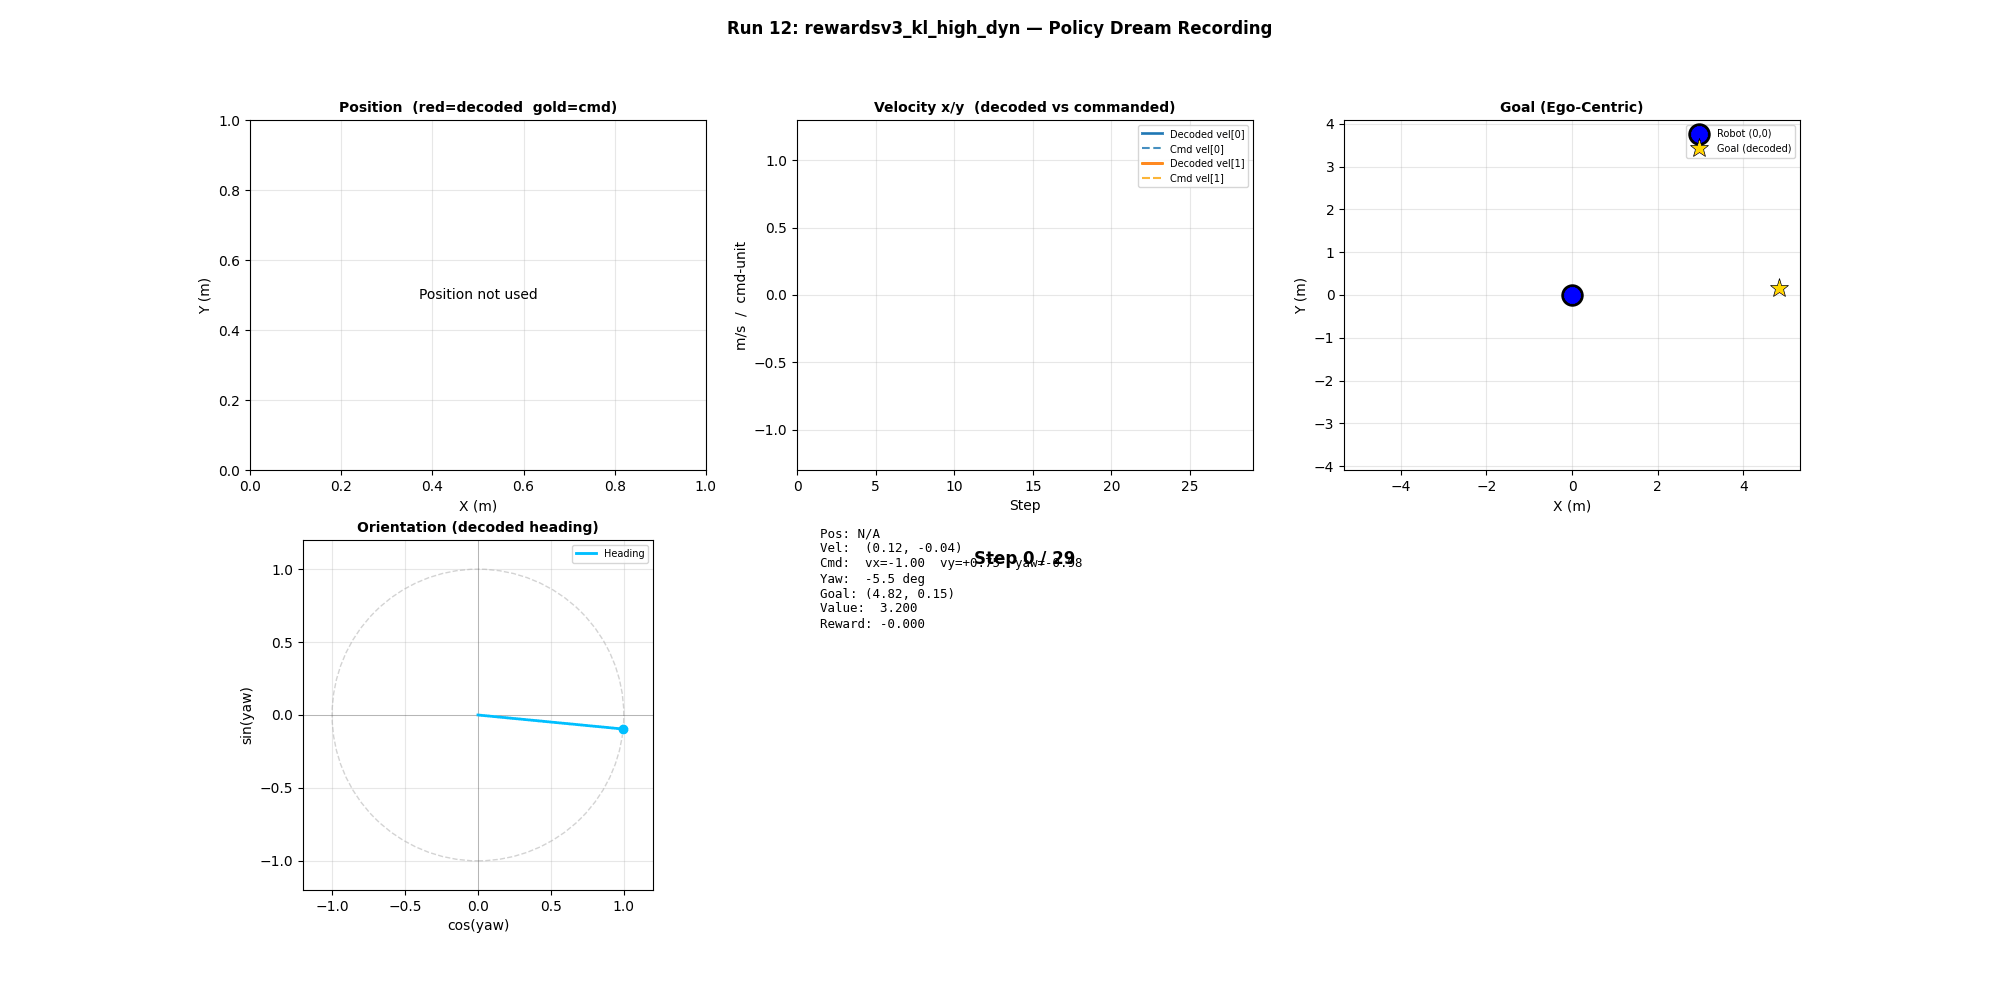

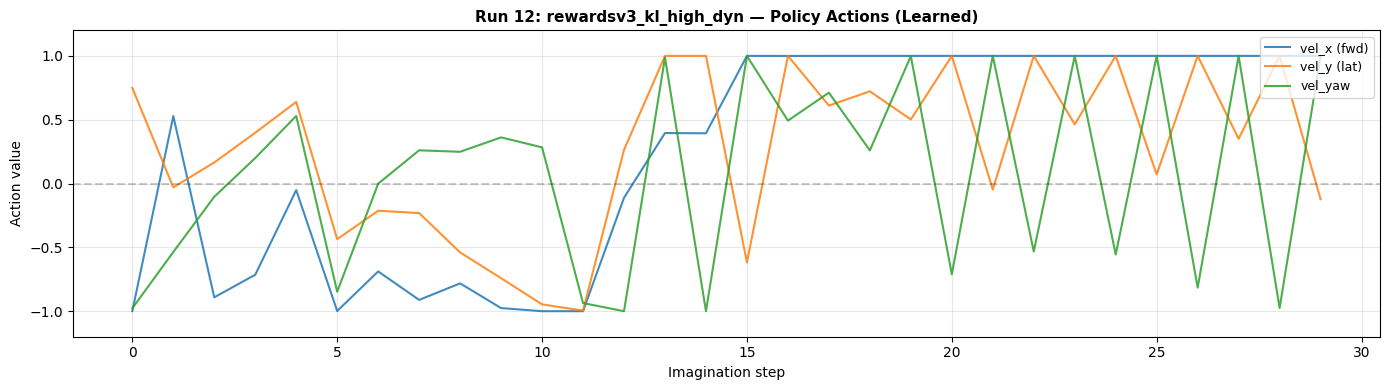

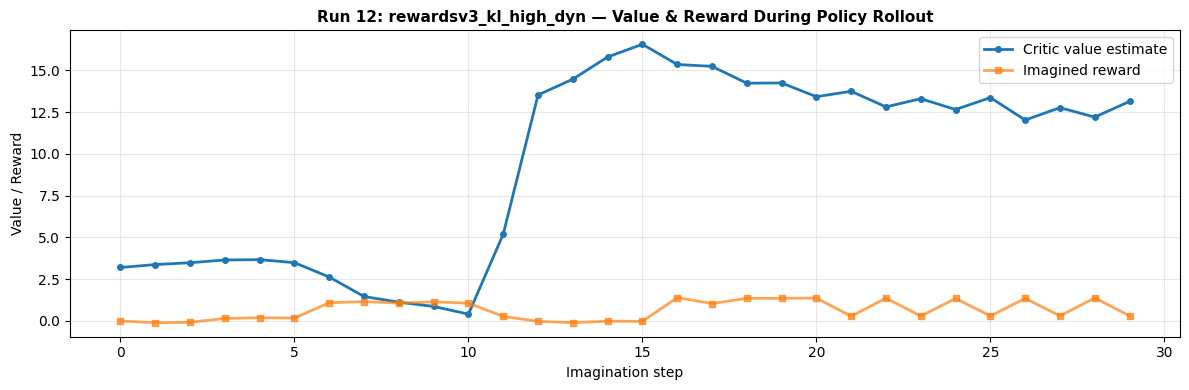

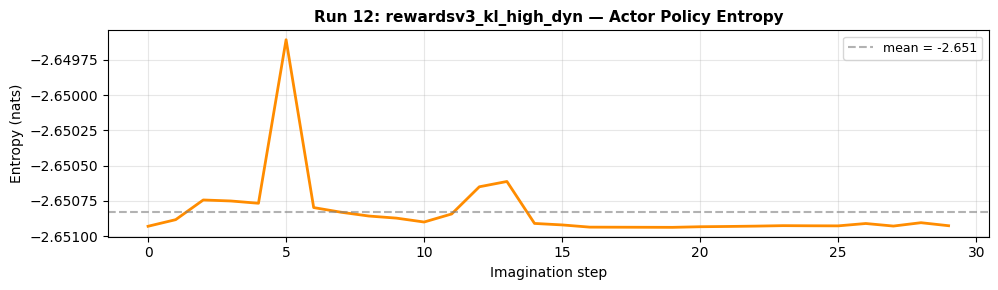

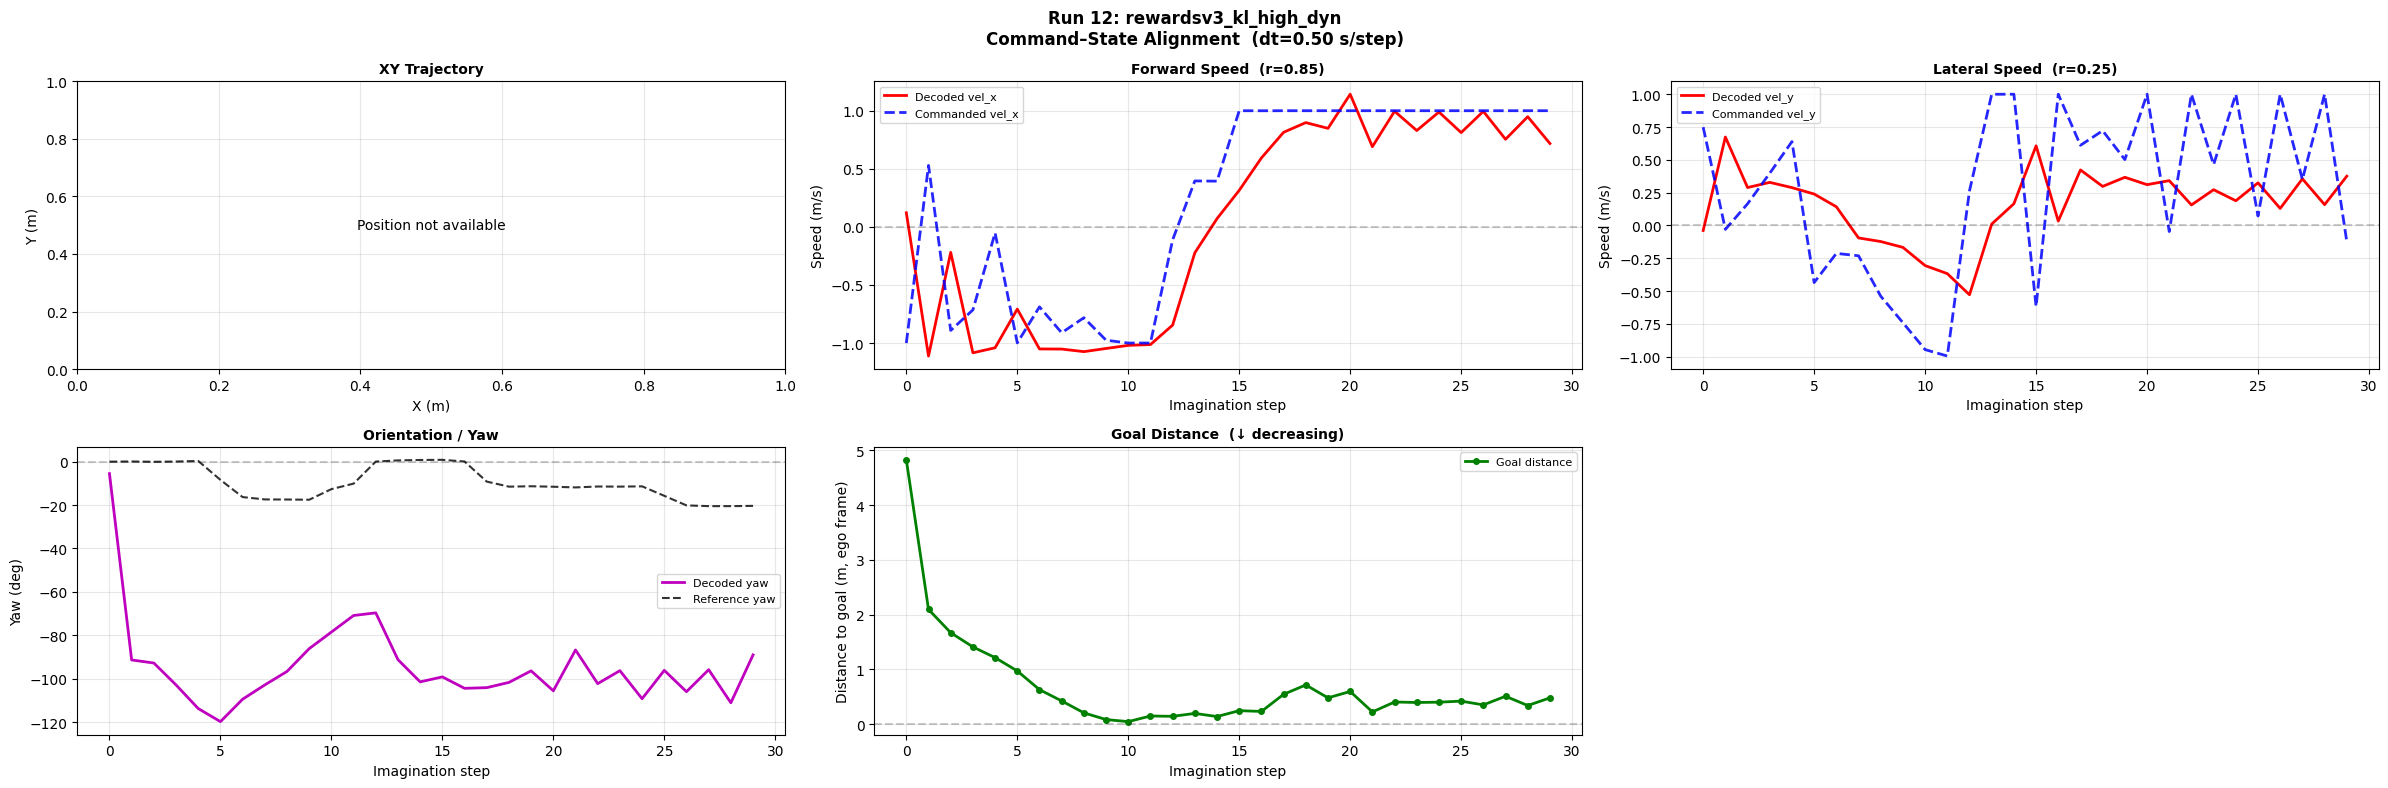

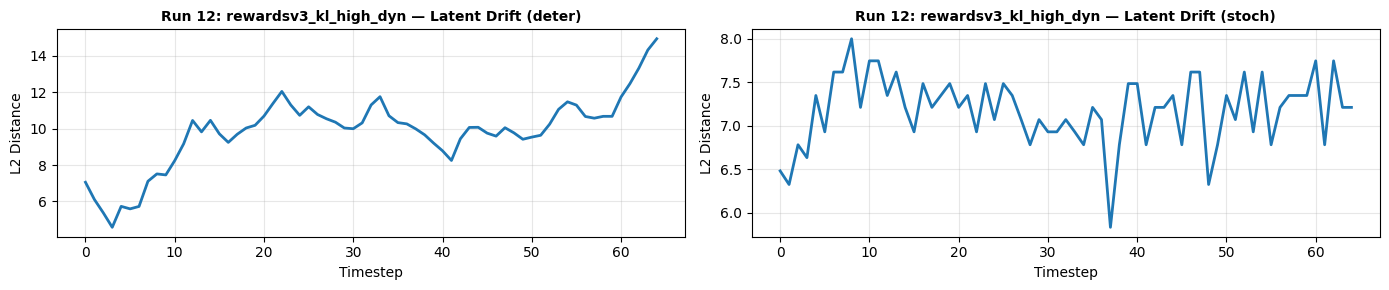

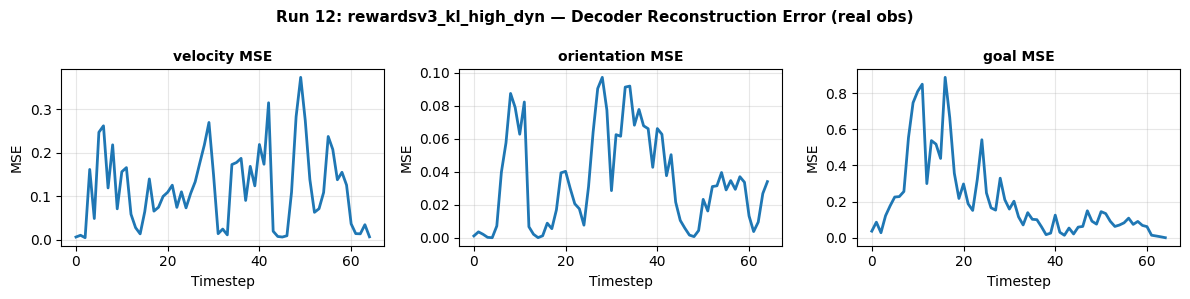


✓ Completed visualizations for 1 run(s)


In [12]:

if rollout_results:
    print("\n" + "="*80)
    print("DETAILED ROLLOUT VISUALIZATIONS")
    print("="*80 + "\n")

    for run_idx, results in rollout_results.items():
        print(f"\nGenerating visualizations for: {results['label']}")
        print("-" * 80)

        gif_path = f'/tmp/policy_dream_run{run_idx}.gif'
        create_policy_state_gif(results['policy'], results['label'],
                                obs_batch_ref=results['obs_batch'],
                                output_path=gif_path, fps=3)

        fig = plot_action_sequences(results['policy'], results['label'])
        plt.show()

        fig = plot_value_predictions(results['policy'], results['label'])
        plt.show()

        plot_policy_entropy(results['policy'], results['label'])

        plot_command_state_alignment(results['policy'], results['label'], obs_batch_ref=results['obs_batch'])

        plot_latent_drift(results['latent_drift'], results['label'])

        plot_reconstruction_error(results['recon_errors'], results['label'])

    print(f"\n{'='*80}")
    print(f"✓ Completed visualizations for {len(rollout_results)} run(s)")
else:
    print("⚠ No rollout results available. Run the previous cell first.")


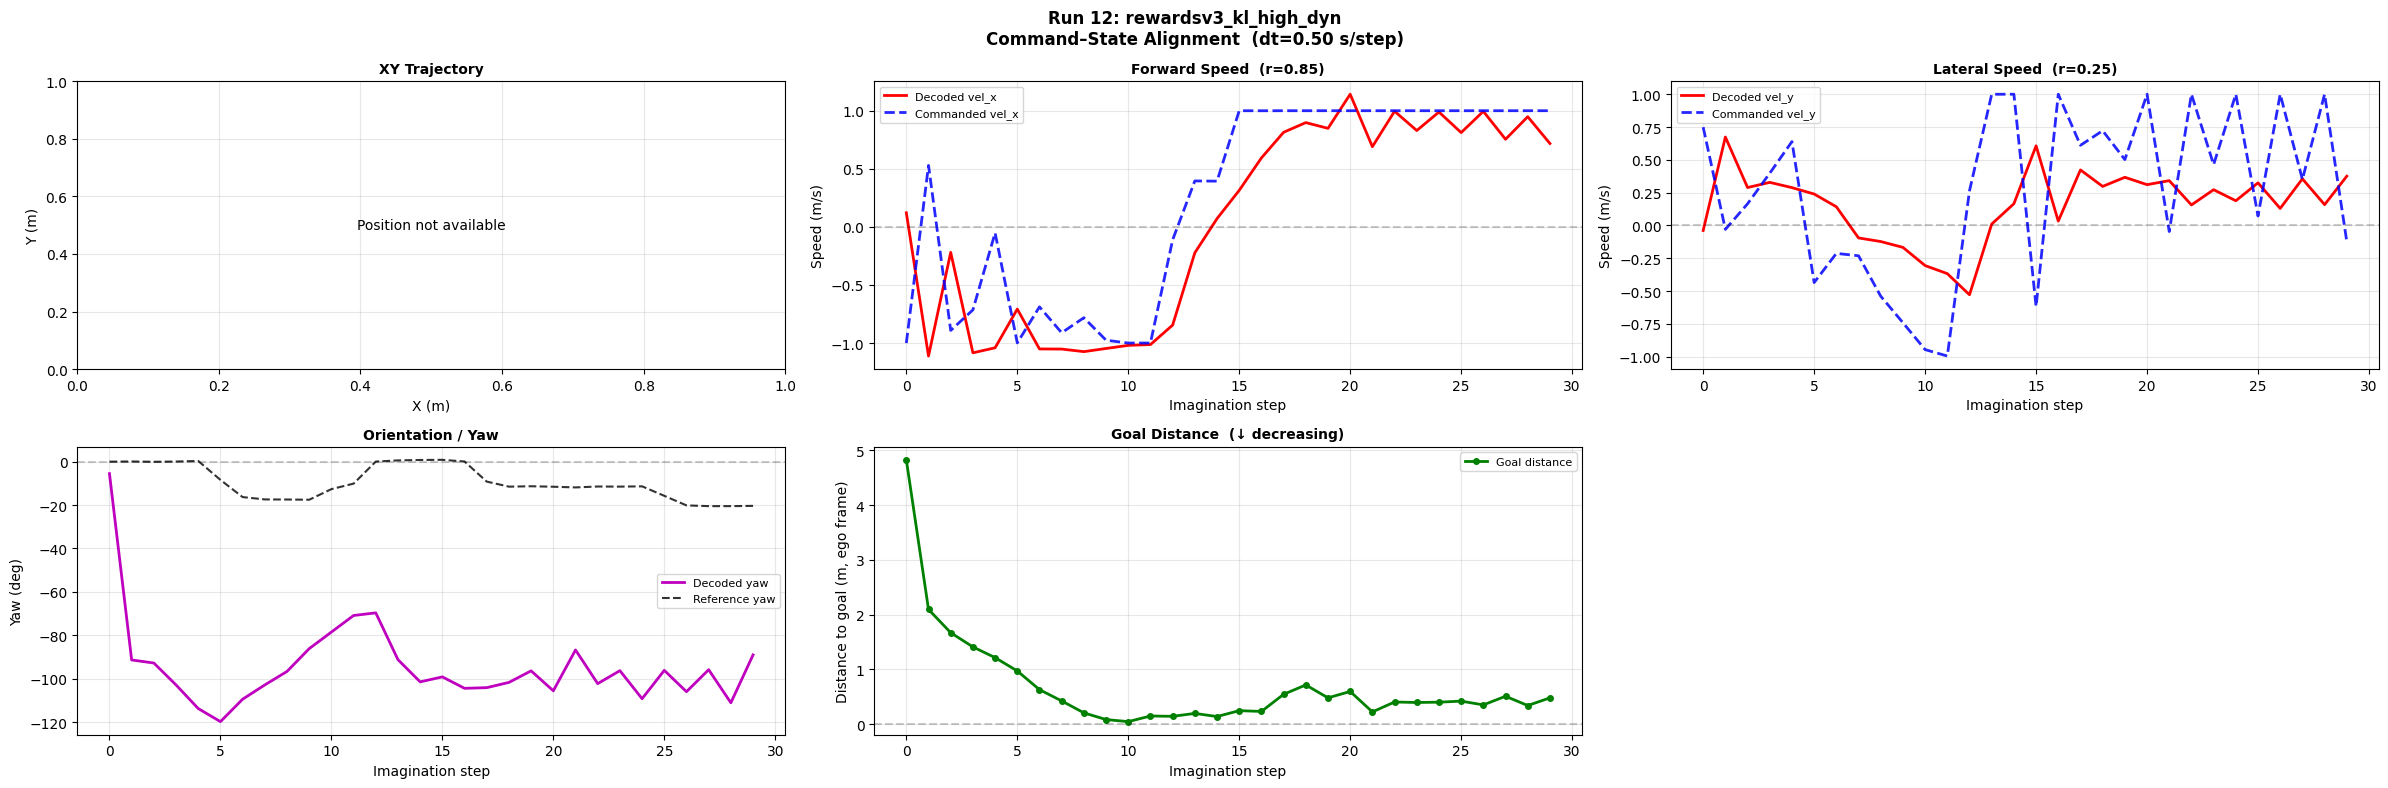

In [13]:
# Quick validation: render command-state alignment for first available run
if 'rollout_results' in globals() and rollout_results:
    _first_run_idx = next(iter(rollout_results.keys()))
    _res = rollout_results[_first_run_idx]
    plot_command_state_alignment(_res['policy'], _res['label'], obs_batch_ref=_res['obs_batch'])
else:
    print('No rollout_results available; run evaluation cell first.')